In [48]:
import requests
from datetime import datetime, timedelta
from tqdm import tqdm
from time import time
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Test API

Get the URLs

In [2]:
patent_url = "https://api.data.gov.sg/v1/technology/ipos/patents"
design_url = "https://api.data.gov.sg/v1/technology/ipos/designs"
trademark_url = "https://api.data.gov.sg/v1/technology/ipos/trademarks"

Test Single Request: Patent

In [3]:
# without any argument this is will give the default = yesterday's date (latest)
sample_request_patent = requests.get(patent_url)
type(sample_request_patent)

requests.models.Response

In [ ]:
# without .json, it just gives the status --> 200 OK  or error 

In [5]:
print(sample_request_patent.json())

{'lodgement_date': '2025-02-10', 'count': 0, 'items': []}


In [6]:
# specify a query parameter
sample_request_patent = requests.get(patent_url, {'lodgement_date': '2019-10-10'})
print(sample_request_patent.json())

{'lodgement_date': '2019-10-10', 'count': 22, 'items': [{'securityInterest': None, 'otherEntries': [{'events': {'description': 'FE CLEAR REPORT ISSUED', 'code': 'PT003', 'eventDate': '2019-10-18'}}, {'events': {'description': 'FILING DATE IS ACCORDED', 'code': 'PT002', 'eventDate': '2019-10-18'}}], 'summary': {'applicationNum': '10201909489R', 'applicationType': 'Normal', 'applicationStatus': 'Pending (Published)', 'publicationPatentNumForOldApplication': None, 'titleOfInvention': 'FOLDABLE TENT COMPRISING TWO UMBRELLA STRUCTURES', 'filingDate': '2019-10-10', 'lodgementDate': '2019-10-10', 'ipc': None, 'dateOfPublication': '2020-05-28'}, 'divisionalApplications': None, 'declarationOfPriority': [{'applicationNum': '1859616', 'country': {'description': 'France', 'code': 'FR'}, 'filingDate': '2018-10-17'}], 'pctApplication': None, 'inventors': [{'name': 'Alexandre GENERO', 'address': 'c/o Decathlon, 4 Boulevard de Mons,<br/>59650 VILLENEUVE D`ASCQ,<br/>France ', 'countryOfResidence': {'de

In [44]:
# specify a query parameter
sample_request_patent = requests.get(patent_url, {'lodgement_date': '2024-07-27'})
print(sample_request_patent.json())

{'lodgement_date': '2024-07-27', 'count': 0, 'items': []}


Test Single Request: Design

In [7]:
# without any argument this is will give the default = yesterday's date (latest)
sample_request_design = requests.get(design_url)
print(sample_request_design.json())

{'lodgement_date': '2025-02-10', 'count': 0, 'items': []}


In [8]:
# without any argument this is will give the default = yesterday's date (latest)
sample_request_design = requests.get(design_url, params = {'lodgement_date': '2020-07-27'})
print(sample_request_design.json())

{'lodgement_date': '2020-07-27', 'count': 3, 'items': [{'securityInterest': None, 'otherEntries': [{'events': {'description': 'DESIGN PUBLISHED IN 09/2020 ', 'code': 'RD024', 'eventDate': '2020-09-04'}}, {'events': {'description': 'APPLICATION APPROVED', 'code': 'RD027', 'eventDate': '2020-08-01'}}, {'events': {'description': 'APPLICATION FILED ON 27/07/2020', 'code': 'RD001', 'eventDate': '2020-07-27'}}], 'statementOfNovelty': 'Novelty resides in the Shape and Configuration AND Pattern and Ornamentation AND Colours as shown in the Representation(s).', 'summary': {'approvedDate': '2020-08-01', 'expiryDate': '2035-07-27', 'applicationNum': '30202008220S', 'ukRegistrationDate': None, 'filingDate': '2020-07-27', 'ukDesignNum': None, 'internationalRegistrationDate': None, 'lodgementDate': '2020-07-27', 'classSubClass': '09-03', 'internationalRegistrationNum': None, 'renewalDueDate': '2025-07-27', 'status': 'Registered'}, 'journals': [{'journalNum': '09/2020', 'journalDate': '2020-09-04'}],

Test Single Request: Trademark

In [11]:
# without any argument this is will give the default = yesterday's date (latest)
sample_request_trademark = requests.get(trademark_url)
print(sample_request_trademark.json())

{'lodgement_date': '2025-02-10', 'count': 0, 'items': []}


In [15]:
# without any argument this is will give the default = yesterday's date (latest)
sample_request_trademark = requests.get(trademark_url, params = {'lodgement_date': '2018-11-11'})
print(sample_request_trademark.json())

{'lodgement_date': '2018-11-11', 'count': 1, 'items': [{'securityInterest': None, 'internationlRegistrationDesignatingSingaporeDetails': None, 'markClauses': None, 'summary': {'applicationType': 'Trade Mark', 'filingDate': '2018-11-12', 'registrationProcedureCompletionDate': None, 'statusUpdateDate': '2019-02-08', 'disclaimerLimitation': None, 'seriesMarkNum': 0, 'journals': [{'journalNum': '006/2019', 'journalDate': '2019-02-08', 'journalStatus': {'description': 'Published', 'code': 'PUB'}}], 'descriptionParticularFeatureOfMark': None, 'expiryDate': None, 'applicationNum': '40201823472S', 'internationalRegDate': None, 'markStatusDate': '2019-02-08', 'tradeMarkType': 'Conventional Mark', 'markStatus': 'Pending (Published)', 'singaporeProtectionDate': '2018-11-12', 'publicationDate': '2019-02-08', 'applicationDate': '2018-11-11'}, 'replacementApplicationMadridReplaces': None, 'HMGcases': None, 'goodsAndServicesSpecifications': [{'goodsServices': 'Cakes; Pastries; Cookies; Bread.', 'clas

## Using Collections

In [60]:
collection_id = 281 # 281 is for IPOS          
url = "https://api-production.data.gov.sg/v2/public/api/collections/{}/metadata".format(collection_id)
        
response = requests.get(url)
print(response.json())

{'code': 0, 'data': {'collectionMetadata': {'collectionId': '281', 'createdAt': '2018-08-22T18:22:52+08:00', 'name': 'IPOS applications API', 'description': 'This dataset contains APIs for the retrieval for the following type of applications:\r\n- Patents\r\n- Designs\r\n- Trademarks', 'lastUpdatedAt': '2019-03-22T13:57:38+08:00', 'coverageStart': '2018-08-22T08:00:00+08:00', 'frequency': 'realtime', 'sources': ['Intellectual Property Office of Singapore'], 'managedBy': 'Intellectual Property Office of Singapore', 'childDatasets': ['d_c49410cc1e293b0a7213a433ab612067', 'd_63bfb01a27595bedef08da39a344402c', 'd_56058f817dc3708f8b97e0876335ac66']}}, 'errorMsg': ''}


In [ ]:
data_id = 'd_c49410cc1e293b0a7213a433ab612067' # 281 is for IPOS          
url = "https://api-production.data.gov.sg/v2/public/api/dataset/{}/metadata".format(data_id)
        
response = requests.get(url)
print(response.json())

# Aggregating Data

## Patent URL

In [46]:
# Define the date range
start_date = datetime(2018, 8, 1)
end_date = datetime(2025, 2, 10)

# This dicitionart will hold all the patent records 
# Key = 'date', Value = 'items'
all_patents = {}

current_date = start_date
start_time = time()
# while tqdm(current_date <= end_date):
while current_date <= end_date:
    # Format the date as expected by the API, e.g., "YYYY-MM-DD"
    date_str = current_date.strftime("%Y-%m-%d")
    #print(date_str)
    
    # Setup query parameters (you can add more parameters if needed)
    params = {'lodgement_date': date_str}
    
    try:
        response = requests.get(patent_url, params=params)
        response.raise_for_status()  # Raises an error for bad responses (4xx, 5xx)
        
        # Assuming the API returns a JSON object
        data = response.json()

        # Add to dictionary only if there's a count (for now, can change later)
        if data.get("count") > 0: 
            all_patents[date_str] = (data.get("count"), data.get("items"))   #tuple: (count_of_items, the_actual_item_list)
        
        # # Optionally, check if there are paginated results here
        # if records:
        #     print(f"Retrieved {len(records)} records for {date_str}")
        #     all_patents.extend(records)
        # else:
        #     print(f"No records for {date_str}")
            
    except requests.RequestException as e:
        print(f"Error on {date_str}: {e}")
    
    # Move to the next day
    current_date += timedelta(days=1)
end_time = time()

# Now, all_patents contains all the data from the date range.
print(f"Total records collected: {len(all_patents)}")
print(f"Time taken: {end_time - start_time}")


Error on 2018-08-02: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-02
Error on 2018-08-03: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-03
Error on 2018-08-06: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-06
Error on 2018-08-07: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-07
Error on 2018-08-08: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-08
Error on 2018-08-10: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-10
Error on 2018-08-20: 502 Server Error: Bad Gateway for url: https://api.data.gov.sg/v1/technology/ipos/patents?lodgement_date=2018-08-20
Error on 2018-08-21: 502 Server Error: Ba

In [48]:
all_patents.keys()

dict_keys(['2018-08-01', '2018-08-04', '2018-08-09', '2018-08-11', '2018-08-12', '2018-08-13', '2018-08-14', '2018-08-15', '2018-08-16', '2018-08-17', '2018-08-18', '2018-09-05', '2018-09-10', '2018-09-11', '2018-09-12', '2018-09-13', '2018-09-14', '2018-09-17', '2018-09-18', '2018-09-22', '2018-09-23', '2018-09-30', '2018-10-06', '2018-10-07', '2018-10-08', '2018-10-09', '2018-10-10', '2018-10-11', '2018-10-12', '2018-10-14', '2018-10-15', '2018-10-16', '2018-10-17', '2018-10-18', '2018-10-19', '2018-10-20', '2018-10-22', '2018-10-23', '2018-10-24', '2018-10-25', '2018-10-26', '2018-10-29', '2018-10-30', '2018-11-03', '2018-11-04', '2018-11-06', '2018-11-07', '2018-11-08', '2018-11-09', '2018-11-17', '2018-11-18', '2018-11-24', '2018-12-03', '2018-12-04', '2018-12-05', '2018-12-06', '2018-12-07', '2018-12-10', '2018-12-11', '2018-12-12', '2018-12-13', '2018-12-14', '2018-12-15', '2018-12-17', '2018-12-22', '2018-12-23', '2018-12-24', '2018-12-26', '2018-12-27', '2018-12-29', '2018-12-

In [49]:
with open('./saved_states/all_patents_dict.pkl', 'wb') as f:
    pickle.dump(all_patents, f)

In [7]:
with open('./saved_states/all_patents_dict.pkl', 'rb') as f:
    all_patents = pickle.load(f)

In [51]:
ls = all_patents.keys()

In [3]:
# Define the date range
start_date = datetime(2018, 8, 22)
end_date = datetime(2025, 2, 10)

# This dicitionart will hold all the patent records 
# Key = 'date', Value = 'items'
all_designs = {}

current_date = start_date
start_time = time()
# while tqdm(current_date <= end_date):
while current_date <= end_date:
    # Format the date as expected by the API, e.g., "YYYY-MM-DD"
    date_str = current_date.strftime("%Y-%m-%d")
    #print(date_str)
    
    # Setup query parameters (you can add more parameters if needed)
    params = {'lodgement_date': date_str}
    
    try:
        response = requests.get(design_url, params=params)
        response.raise_for_status()  # Raises an error for bad responses (4xx, 5xx)
        
        # Assuming the API returns a JSON object
        data = response.json()

        # Add to dictionary only if there's a count (for now, can change later)
        if data.get("count") > 0: 
            all_designs[date_str] = (data.get("count"), data.get("items"))   #tuple: (count_of_items, the_actual_item_list)
        
        # # Optionally, check if there are paginated results here
        # if records:
        #     print(f"Retrieved {len(records)} records for {date_str}")
        #     all_patents.extend(records)
        # else:
        #     print(f"No records for {date_str}")
            
    except requests.RequestException as e:
        print(f"Error on {date_str}: {e}")
    
    # Move to the next day
    current_date += timedelta(days=1)
end_time = time()

# Now, all_patents contains all the data from the date range.
print(f"Total records collected: {len(all_designs)}")
print(f"Time taken: {end_time - start_time}")


Total records collected: 525
Time taken: 931.8037278652191


In [6]:
with open('./saved_states/all_designs_dict.pkl', 'wb') as f:
    pickle.dump(all_designs, f)

In [8]:
with open('./saved_states/all_designs_dict.pkl', 'rb') as f:
    all_designs = pickle.load(f)

In [7]:
all_designs.keys()

dict_keys(['2018-08-22', '2018-08-24', '2018-08-27', '2018-08-28', '2018-08-29', '2018-08-30', '2018-08-31', '2018-09-03', '2018-09-04', '2018-09-05', '2018-09-06', '2018-09-07', '2018-09-10', '2018-09-11', '2018-09-12', '2018-09-13', '2018-09-17', '2018-09-18', '2018-09-19', '2018-09-20', '2018-09-21', '2018-09-24', '2018-09-25', '2018-09-26', '2018-09-27', '2018-09-28', '2018-10-01', '2018-10-02', '2018-10-03', '2018-10-04', '2018-10-05', '2018-10-09', '2018-10-10', '2018-10-11', '2018-10-12', '2018-10-15', '2018-10-16', '2018-10-17', '2018-10-19', '2018-10-22', '2018-10-23', '2018-10-24', '2018-10-25', '2018-10-26', '2018-10-29', '2018-10-30', '2018-10-31', '2018-11-01', '2018-11-02', '2018-11-05', '2018-11-06', '2018-11-07', '2018-11-08', '2018-11-09', '2018-11-11', '2018-11-12', '2018-11-13', '2018-11-14', '2018-11-15', '2018-11-16', '2018-11-17', '2018-11-19', '2018-11-20', '2018-11-21', '2018-11-22', '2018-11-23', '2018-11-26', '2018-11-27', '2018-11-28', '2018-11-29', '2018-11-

In [5]:
# Define the date range
start_date = datetime(2020, 1, 1)
end_date = datetime(2020, 12, 12)

# This dicitionart will hold all the patent records 
# Key = 'date', Value = 'items'
tms_2020 = {}

current_date = start_date
start_time = time()
# while tqdm(current_date <= end_date):
while current_date <= end_date:
    # Format the date as expected by the API, e.g., "YYYY-MM-DD"
    date_str = current_date.strftime("%Y-%m-%d")
    #print(date_str)
    
    # Setup query parameters (you can add more parameters if needed)
    params = {'lodgement_date': date_str}
    
    try:
        response = requests.get(trademark_url, params=params)
        response.raise_for_status()  # Raises an error for bad responses (4xx, 5xx)
        
        # Assuming the API returns a JSON object
        data = response.json()

        # Add to dictionary only if there's a count (for now, can change later)
        if data.get("count") > 0: 
            tms_2020[date_str] = (data.get("count"), data.get("items"))   #tuple: (count_of_items, the_actual_item_list)
        
        # # Optionally, check if there are paginated results here
        # if records:
        #     print(f"Retrieved {len(records)} records for {date_str}")
        #     all_patents.extend(records)
        # else:
        #     print(f"No records for {date_str}")
            
    except requests.RequestException as e:
        print(f"Error on {date_str}: {e}")
    
    # Move to the next day
    current_date += timedelta(days=1)
end_time = time()

# Now, all_patents contains all the data from the date range.
print(f"Total records collected: {len(tms_2020)}")
print(f"Time taken: {end_time - start_time}")

Total records collected: 276
Time taken: 472.8655297756195


In [6]:
with open('./saved_states/tms_2020_dict.pkl', 'wb') as f:
    pickle.dump(tms_2020, f)

In [ ]:
with open('./saved_states/tms_2020_dict.pkl', 'rb') as f:
    tms_2020 = pickle.load(f)

In [ ]:
# Define the date range
start_date = datetime(2019, 1, 1)
end_date = datetime(2019, 12, 12)

# This dicitionart will hold all the patent records 
# Key = 'date', Value = 'items'
tms_2020 = {}

current_date = start_date
start_time = time()
# while tqdm(current_date <= end_date):
while current_date <= end_date:
    # Format the date as expected by the API, e.g., "YYYY-MM-DD"
    date_str = current_date.strftime("%Y-%m-%d")
    #print(date_str)
    
    # Setup query parameters (you can add more parameters if needed)
    params = {'lodgement_date': date_str}
    
    try:
        response = requests.get(trademark_url, params=params)
        response.raise_for_status()  # Raises an error for bad responses (4xx, 5xx)
        
        # Assuming the API returns a JSON object
        data = response.json()

        # Add to dictionary only if there's a count (for now, can change later)
        if data.get("count") > 0: 
            tms_2020[date_str] = (data.get("count"), data.get("items"))   #tuple: (count_of_items, the_actual_item_list)
        
        # # Optionally, check if there are paginated results here
        # if records:
        #     print(f"Retrieved {len(records)} records for {date_str}")
        #     all_patents.extend(records)
        # else:
        #     print(f"No records for {date_str}")
            
    except requests.RequestException as e:
        print(f"Error on {date_str}: {e}")
    
    # Move to the next day
    current_date += timedelta(days=1)
end_time = time()

# Now, all_patents contains all the data from the date range.
print(f"Total records collected: {len(tms_2020)}")
print(f"Time taken: {end_time - start_time}")

In [ ]:
# Define the date range
start_date = datetime(2018, 8, 22)
end_date = datetime(2025, 2, 11)

# This dicitionart will hold all the patent records 
# Key = 'date', Value = 'items'
all_tms = {}

current_date = start_date
start_time = time()
# while tqdm(current_date <= end_date):
while current_date <= end_date:
    # Format the date as expected by the API, e.g., "YYYY-MM-DD"
    date_str = current_date.strftime("%Y-%m-%d")
    #print(date_str)
    
    # Setup query parameters (you can add more parameters if needed)
    params = {'lodgement_date': date_str}
    
    try:
        response = requests.get(trademark_url, params=params)
        response.raise_for_status()  # Raises an error for bad responses (4xx, 5xx)
        
        # Assuming the API returns a JSON object
        data = response.json()

        # Add to dictionary only if there's a count (for now, can change later)
        if data.get("count") > 0: 
            all_tms[date_str] = (data.get("count"), data.get("items"))   #tuple: (count_of_items, the_actual_item_list)
        
        # # Optionally, check if there are paginated results here
        # if records:
        #     print(f"Retrieved {len(records)} records for {date_str}")
        #     all_patents.extend(records)
        # else:
        #     print(f"No records for {date_str}")
            
    except requests.RequestException as e:
        print(f"Error on {date_str}: {e}")
    
    # Move to the next day
    current_date += timedelta(days=1)
end_time = time()

# Now, all_patents contains all the data from the date range.
print(f"Total records collected: {len(all_tms)}")
print(f"Time taken: {end_time - start_time}")

In [ ]:
with open('./saved_states/all_tms_dict.pkl', 'wb') as f:
    pickle.dump(all_tms, f)
        
with open('./saved_states/all_tms_dict.pkl', 'rb') as f:
    all_tms = pickle.load(f)

In [ ]:
all_tms.keys()

# Data Exploration

## Dates

In [44]:
def filter_date_values(dict, year = 2020): 
    dates = []
    vals = []

    for d, i in dict.items(): 
        date = datetime.strptime(d, "%Y-%m-%d")
        if date.year == year:
            dates.append(date)
            vals.append(i[0])

    return dates, vals

In [54]:
def plot_dates(dates_x, counts_y, title = ''): 
    # Create the plot
    plt.figure(figsize=(20, 4))
    plt.bar(dates_x, counts_y)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title(f"Plot of Dates (Dictionary Keys) {title}")
    plt.xticks(rotation=90)
    plt.grid(True)

    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Set tick every week
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))  # Format as YYYY-MM-DD

    # Show the plot
    plt.show()


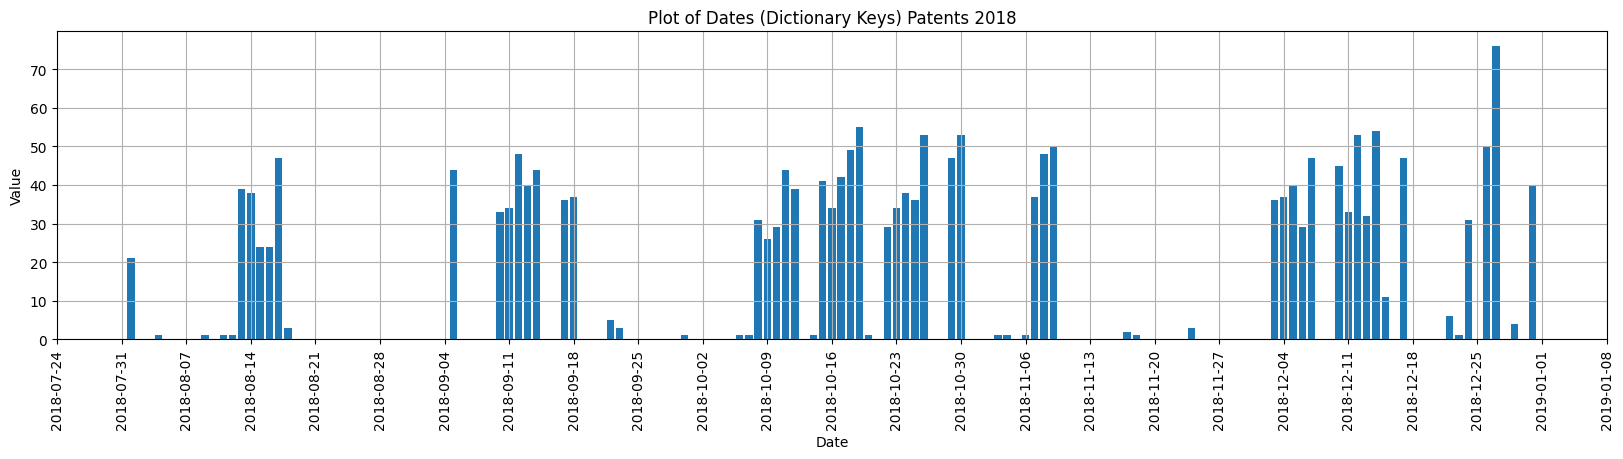

In [57]:
patent_dates_2018, patent_vals_2018 = filter_date_values(all_patents, year=2018)
plot_dates(patent_dates_2018, patent_vals_2018, title = 'Patents 2018')


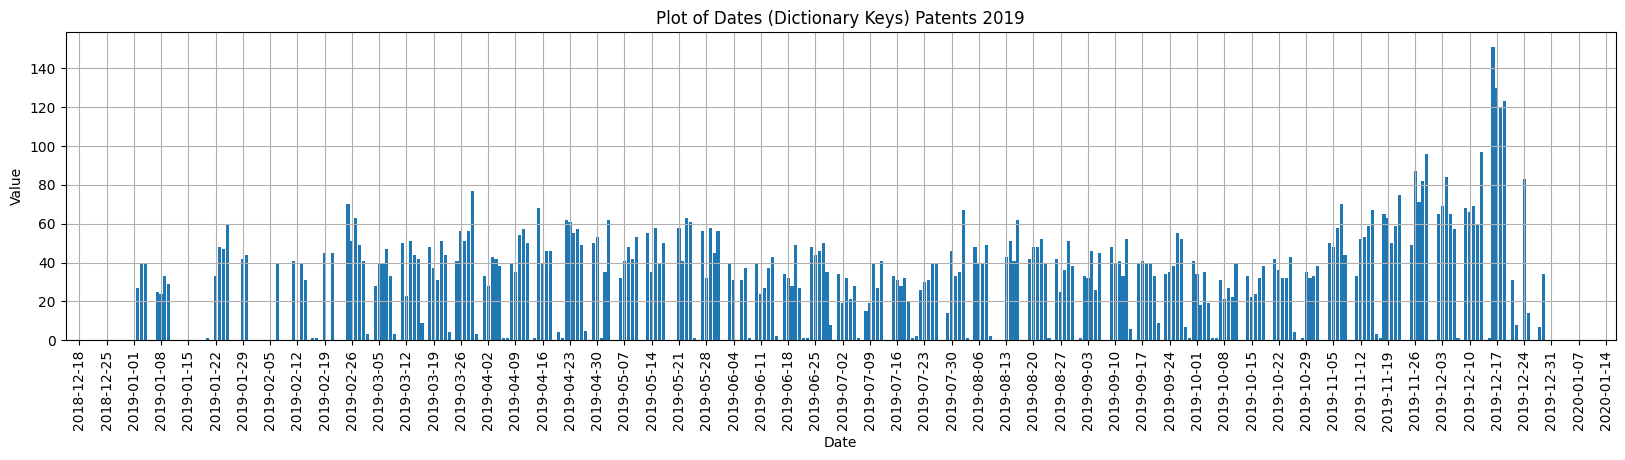

In [58]:
patent_dates_2019, patent_vals_2019 = filter_date_values(all_patents, year=2019)
plot_dates(patent_dates_2019, patent_vals_2019, title = 'Patents 2019')


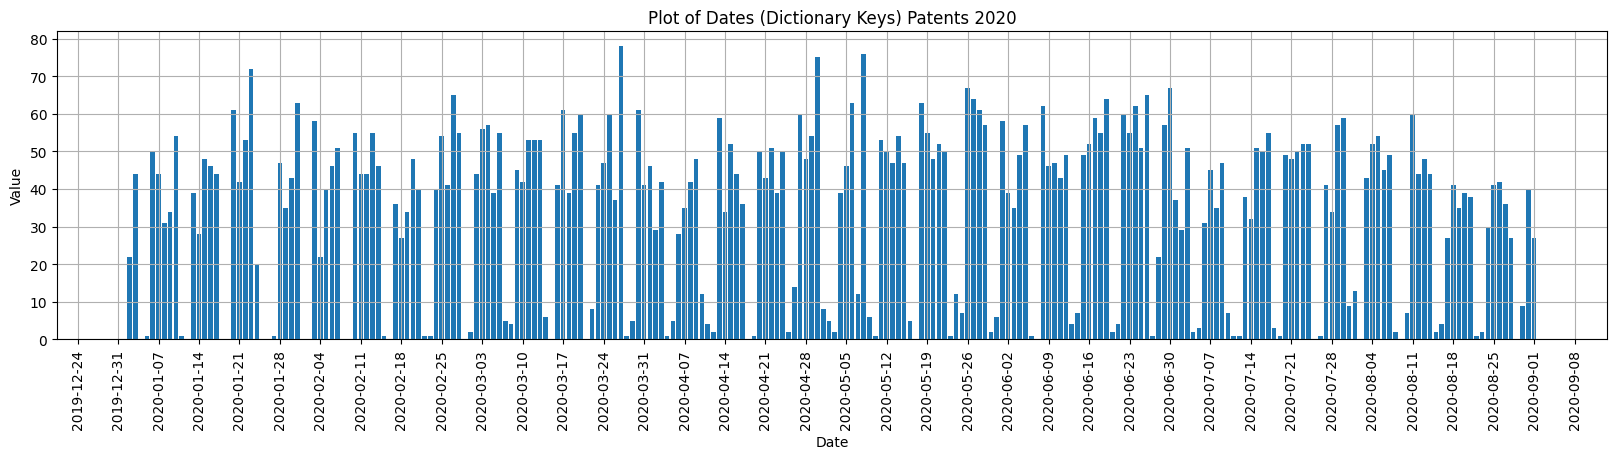

In [59]:
patent_dates_2020, patent_vals_2020 = filter_date_values(all_patents, year=2020)
plot_dates(patent_dates_2020, patent_vals_2020, title = 'Patents 2020')


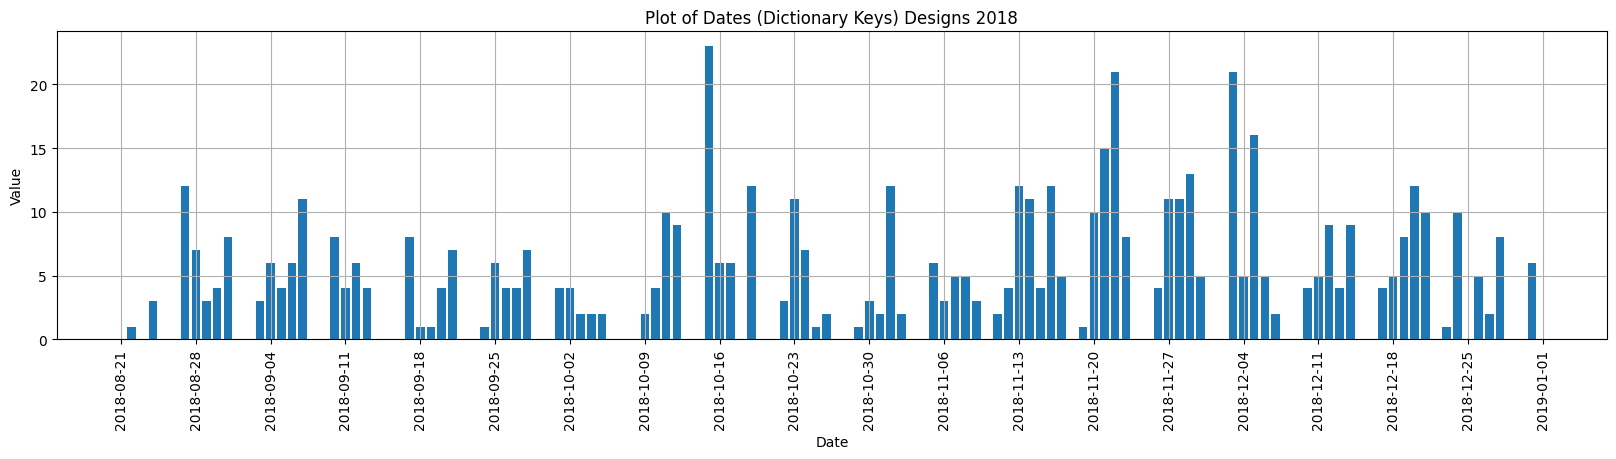

In [61]:
design_dates_2018, design_vals_2018 = filter_date_values(all_designs, year=2018)
plot_dates(design_dates_2018, design_vals_2018, title = 'Designs 2018')


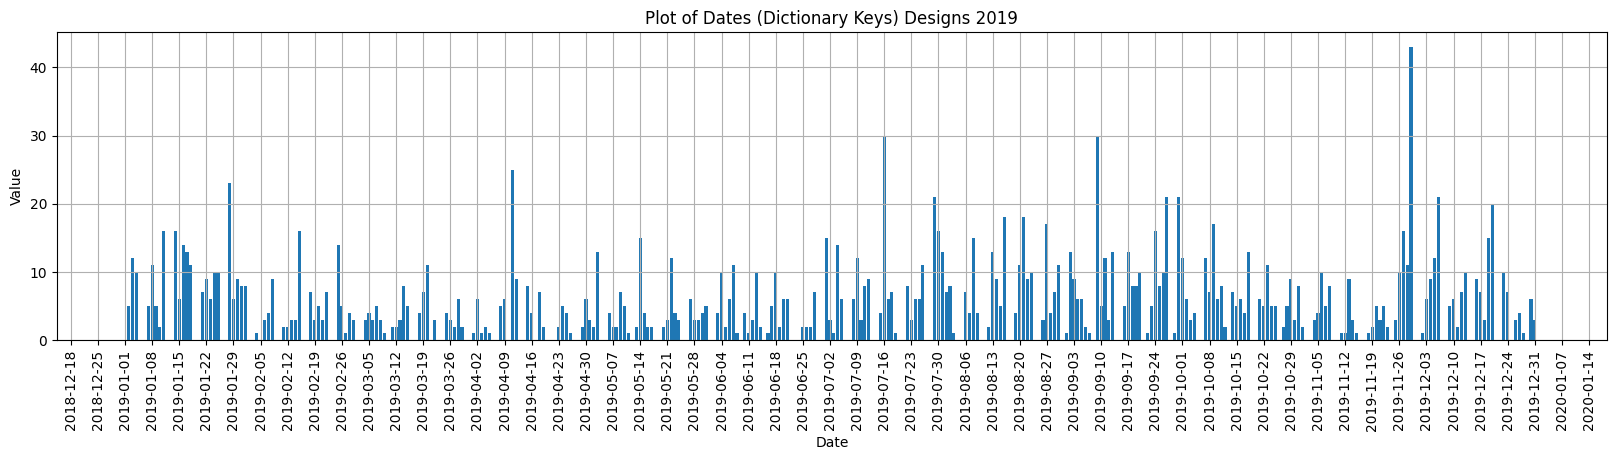

In [62]:
design_dates_2019, design_vals_2019 = filter_date_values(all_designs, year=2019)
plot_dates(design_dates_2019, design_vals_2019, title = 'Designs 2019')


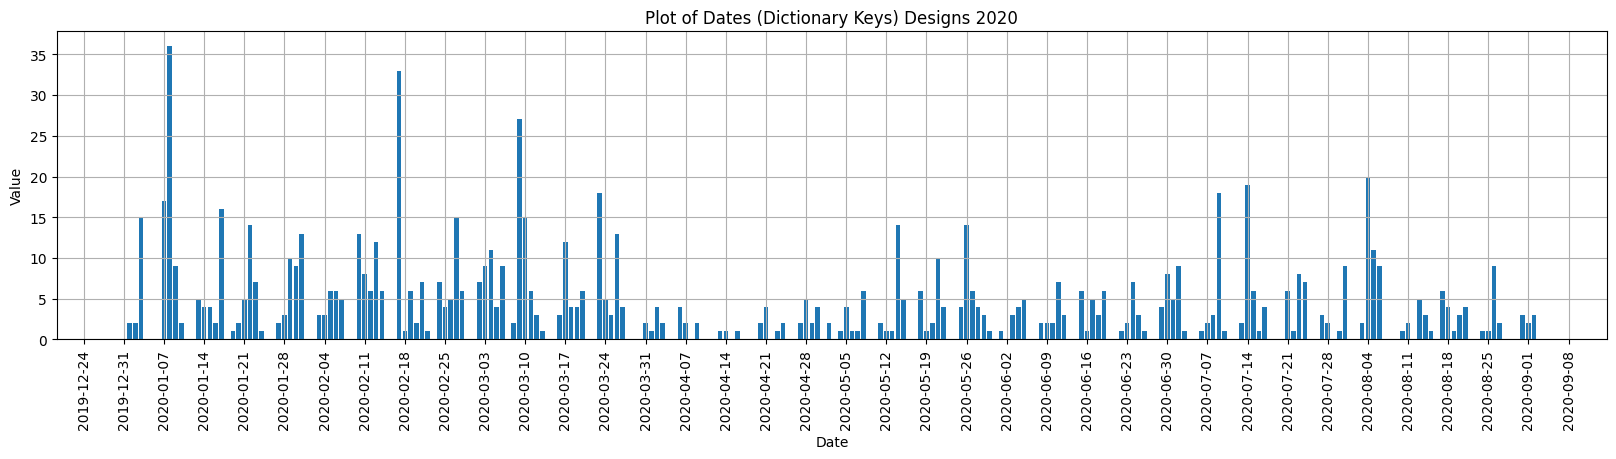

In [63]:
design_dates_2020, design_vals_2020 = filter_date_values(all_designs, year=2020)
plot_dates(design_dates_2020, design_vals_2020, title = 'Designs 2020')


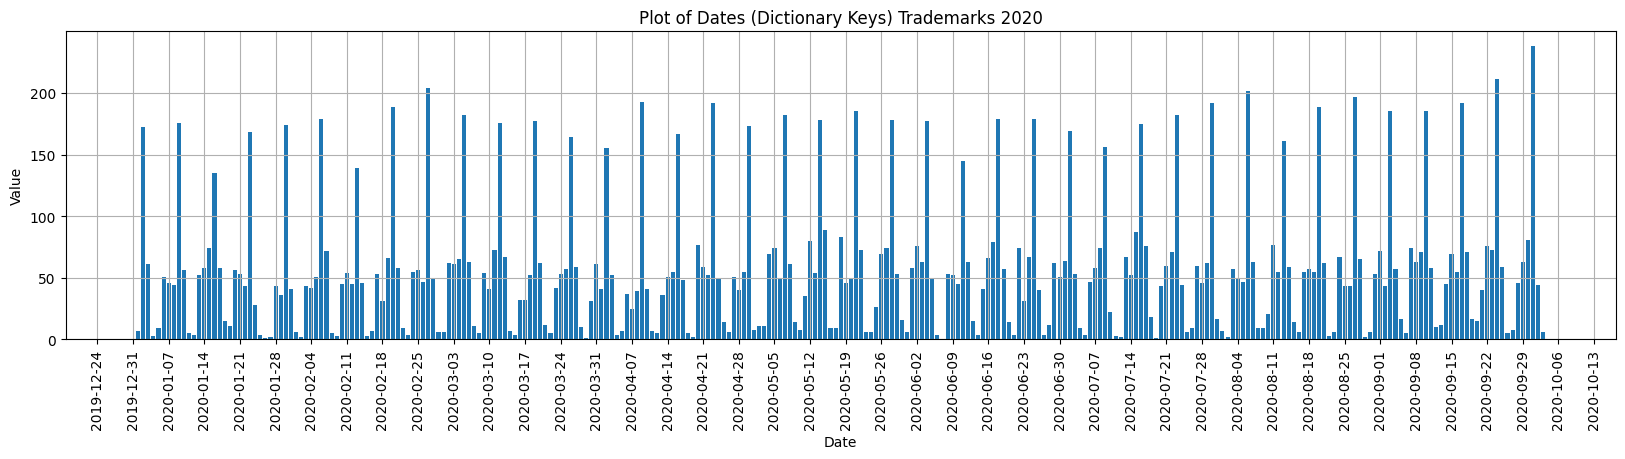

In [64]:
tms_dates_2020, tms_vals_2020 = filter_date_values(tms_2020, year=2020)
plot_dates(tms_dates_2020, tms_vals_2020, title = 'Trademarks 2020')


In [73]:
patent_dates = set(all_patents.keys())
design_dates = set(all_designs.keys())

patent_2020_dates = set(patent_dates_2020)
design_2020_dates = set(design_dates_2020)
tms_2020_dates = set(tms_dates_2020)

In [68]:
print(len(patent_dates))
print(len(design_dates))
print(len(patent_dates & design_dates))

566
525
438


In [85]:
print("Patents ", len(patent_2020_dates))
print("Designs ", len(design_2020_dates))
print("Trademarks ", len(tms_2020_dates))
print("\n")
print("Patent & Designs ", len(patent_2020_dates & design_2020_dates))
print("Patent & Tradmarks ", len(patent_2020_dates & tms_2020_dates))
print("Design & Trademarks",len(design_2020_dates & tms_2020_dates))
print("Patents & Design & Trademarks",len(design_2020_dates & tms_2020_dates & patent_2020_dates))


Patents  223
Designs  168
Trademarks  276


Patent & Designs  165
Patent & Tradmarks  223
Design & Trademarks 168
Patents & Design & Trademarks 165


**If there is a patent or design application --> there is a trademark application.**
 - but there may be a trademark application not linked to patents or designs 
 - joins with trademark can give us some useful info 

## Inside the Data

In [134]:
all_patents['2018-08-14'][1][0]

{'summary': {'applicationNum': '10201806858U',
  'applicationStatus': 'Pending (Not Published)',
  'titleOfInvention': 'POLYMER BASED CAMOUFLAGE MATERIAL AND A METHOD OF FORMING THE SAME',
  'filingDate': '2018-08-14',
  'lodgementDate': '2018-08-14'},
 'applicationNum': '10201806858U',
 'applicant': [{'name': 'NANYANG TECHNOLOGICAL UNIVERSITY',
   'soleProprietorPartnerName': None}],
 'agent': [{'name': 'VIERING, JENTSCHURA & PARTNER LLP',
   'actionRepresenting': 'For all matters relating to the application, registration/grant, except those matters expressly excluded ',
   'uenCompanyCode': 'T06LL1666B',
   'representativeName': None}],
 'declarationOfPriority': None,
 'documents': []}

In [133]:
all_patents['2018-08-14'][1][1]

{'securityInterest': None,
 'summary': {'applicationNum': '10201806859Y',
  'applicationType': 'Normal',
  'applicationStatus': 'Pending (Published)',
  'publicationPatentNumForOldApplication': None,
  'titleOfInvention': 'Apparatus For Gravity Emptying Bottles Containing Frozen Blood Product Comprising A Unit For Monitoring Emptying And Emptying Method',
  'filingDate': '2018-08-14',
  'lodgementDate': '2018-08-14',
  'ipc': None,
  'dateOfPublication': '2019-05-30'},
 'divisionalApplications': None,
 'declarationOfPriority': [{'applicationNum': '17382713.0',
   'country': {'description': 'European Patent Office (EPO)', 'code': 'EP'},
   'filingDate': '2017-10-24'}],
 'pctApplication': None,
 'inventors': [{'name': 'FLETA COIT, Daniel',
   'address': 'C/ Serrat Dels Rocs,<br/>44 08415 - Bigues,<br/>Barcelona, Spain ',
   'countryOfResidence': {'description': 'Spain', 'code': 'ES'},
   'nationality': 'SPANISH'},
  {'name': 'GOMEZ FLORES, Jose Luis',
   'address': "Passatge De L'amistat

In [136]:
all_patents['2018-08-14'][1][2]

{'securityInterest': None,
 'summary': {'applicationNum': '10201806860P',
  'applicationType': 'Normal',
  'applicationStatus': 'Pending (Published)',
  'publicationPatentNumForOldApplication': None,
  'titleOfInvention': 'Automated Container Emptying Device Equipped With Means For Collecting And Gravity Emptying Containers And Comprising A Product Collection Zone',
  'filingDate': '2018-08-14',
  'lodgementDate': '2018-08-14',
  'ipc': None,
  'dateOfPublication': '2019-05-30'},
 'divisionalApplications': None,
 'declarationOfPriority': [{'applicationNum': '17382714.8',
   'country': {'description': 'European Patent Office (EPO)', 'code': 'EP'},
   'filingDate': '2017-10-24'}],
 'pctApplication': None,
 'inventors': [{'name': 'FLETA COIT, Daniel ',
   'address': 'C/ Serrat Dels Rocs,<br/>44 08415 - Bigues,<br/>Barcelona, Spain ',
   'countryOfResidence': {'description': 'Spain', 'code': 'ES'},
   'nationality': 'SPANISH'},
  {'name': 'GOMEZ FLORES, Jose Luis ',
   'address': "Passatge

In [104]:
for app in all_patents['2018-08-14'][1]: 
    print(app.keys())

dict_keys(['summary', 'applicationNum', 'applicant', 'agent', 'declarationOfPriority', 'documents'])
dict_keys(['securityInterest', 'summary', 'divisionalApplications', 'declarationOfPriority', 'pctApplication', 'inventors', 'grantAndRenewal', 'rupka', 'documents', 'license', 'agentCorrespondenceDetails', 'applicationNum', 'applicant', 'hmgStatus', 'transferOfOwnership'])
dict_keys(['securityInterest', 'summary', 'divisionalApplications', 'declarationOfPriority', 'pctApplication', 'inventors', 'grantAndRenewal', 'rupka', 'documents', 'license', 'agentCorrespondenceDetails', 'applicationNum', 'applicant', 'hmgStatus', 'transferOfOwnership'])
dict_keys(['securityInterest', 'summary', 'divisionalApplications', 'declarationOfPriority', 'pctApplication', 'inventors', 'grantAndRenewal', 'rupka', 'documents', 'license', 'agentCorrespondenceDetails', 'applicationNum', 'applicant', 'hmgStatus', 'transferOfOwnership'])
dict_keys(['summary', 'applicationNum', 'applicant', 'agent', 'declarationOfP

In [108]:
status = []
for app in all_patents['2018-08-14'][1]: 
    print(app['summary']['applicationStatus'])
    status.append(app['summary']['applicationStatus'])

Pending (Not Published)
Pending (Published)
Pending (Published)
Pending (Published)
Abandoned 
Pending (Published)
Pending (Published)
Abandoned 
Abandoned 
Pending (Published)
Pending (Published)
Pending (Published)
Pending (Published)
Abandoned 
Abandoned (Extension of Time Possible)
Abandoned (Extension of Time Possible)
Abandoned (Extension of Time Possible)
Patent In Force
Pending (Published)
Pending (Published)
Pending (Published)
Pending (Published)
Patent In Force
Pending (Published)
Pending (Published)
Refused 
Pending (Published)
Pending (Published)
Pending (Published)
Abandoned (Extension of Time Possible)
Patent In Force
Pending (Published)
Pending (Published)
Pending (Published)
Pending (Published)
Patent In Force
Patent In Force
Abandoned (Extension of Time Possible)


These are application status

In [110]:
set(status)

{'Abandoned ',
 'Abandoned (Extension of Time Possible)',
 'Patent In Force',
 'Pending (Not Published)',
 'Pending (Published)',
 'Refused '}

In [111]:
for app in all_patents['2018-08-14'][1]:
    f_date = app['summary']['filingDate']
    if f_date != '2018-08-14':
        print(f_date)

2013-02-22
2015-02-09
2014-08-28
2017-03-03
2017-02-21
2017-02-16
2017-02-13
2017-03-13
2017-02-15
2017-02-24
2017-02-15
2017-02-13
2017-03-30
2017-02-15
2017-02-24
2017-02-08
2017-03-22
2017-02-16
2017-02-24
2016-02-26
2017-02-17
2016-02-26
2017-03-07
2017-03-29
2017-03-02
2017-03-17
2017-02-27


Some filing dates are old!!

In [113]:
for app in all_patents['2018-08-14'][1]:
    f_date = app['summary']['filingDate']
    if f_date != '2018-08-14':
        #print(f_date)
        print(app['summary']['applicationStatus'])

Pending (Published)
Pending (Published)
Pending (Published)
Abandoned (Extension of Time Possible)
Abandoned (Extension of Time Possible)
Abandoned (Extension of Time Possible)
Patent In Force
Pending (Published)
Pending (Published)
Pending (Published)
Pending (Published)
Patent In Force
Pending (Published)
Pending (Published)
Refused 
Pending (Published)
Pending (Published)
Pending (Published)
Abandoned (Extension of Time Possible)
Patent In Force
Pending (Published)
Pending (Published)
Pending (Published)
Pending (Published)
Patent In Force
Patent In Force
Abandoned (Extension of Time Possible)


In [114]:
for app in all_patents['2018-08-14'][1]:
    f_date = app['summary']['filingDate']
    if f_date != '2018-08-14':
        print(app['summary']['lodgementDate'])

2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14
2018-08-14


I think lodgement date => when it's lodged into records/API(?), while filing date is when the application was filed

In [117]:
for app in all_patents['2020-03-13'][1]:
    f_date = app['summary']['filingDate']
    if f_date != '2020-03-13':
        print(f_date)

2016-03-16
2015-11-04
2015-06-16
2014-12-17
2019-07-30
2013-03-01
2018-10-12
2018-09-06
2018-09-20
2018-10-31
2018-07-12
2018-09-17
2017-09-29
2017-09-14
2018-09-14
2018-09-10
2018-10-03
2018-09-27
2018-09-13
2018-09-13
2018-08-28
2018-09-21
2018-07-31
2018-09-10
2018-09-19
2018-08-20
2018-09-10
2018-10-15
2018-08-20
2018-09-19
2018-09-18
2018-09-14
2018-10-01
2018-11-14
2018-09-07
2018-09-21
2018-12-06
2018-10-01
2017-09-13
2018-09-14
2018-10-17


In [118]:
for app in all_patents['2020-03-13'][1]:
    f_date = app['summary']['filingDate']
    if f_date > '2020-03-13':
        print(f_date)

In [126]:
num = '10201806858U'
for p in all_patents.values(): 
    for app in p[1]: 
        if app['summary']['applicationNum'] == '10201806858U': 
            print(app['summary'])

{'applicationNum': '10201806858U', 'applicationStatus': 'Pending (Not Published)', 'titleOfInvention': 'POLYMER BASED CAMOUFLAGE MATERIAL AND A METHOD OF FORMING THE SAME', 'filingDate': '2018-08-14', 'lodgementDate': '2018-08-14'}


In [128]:
for app in all_patents['2018-08-14'][1]:
    f_date = app['summary']['filingDate']
    if f_date != '2018-08-14':
        #print(f_date)
        print(app['summary']['applicationNum'])
        print(app['summary']['applicationStatus'])

10201806867V
Pending (Published)
10201806887T
Pending (Published)
10201806890V
Pending (Published)
11201806861S
Abandoned (Extension of Time Possible)
11201806862Q
Abandoned (Extension of Time Possible)
11201806863W
Abandoned (Extension of Time Possible)
11201806864U
Patent In Force
11201806865Y
Pending (Published)
11201806866X
Pending (Published)
11201806868T
Pending (Published)
11201806869R
Pending (Published)
11201806870W
Patent In Force
11201806872Y
Pending (Published)
11201806873R
Pending (Published)
11201806874Q
Refused 
11201806875U
Pending (Published)
11201806876T
Pending (Published)
11201806877X
Pending (Published)
11201806879S
Abandoned (Extension of Time Possible)
11201806880Q
Patent In Force
11201806881W
Pending (Published)
11201806882U
Pending (Published)
11201806883P
Pending (Published)
11201806886S
Pending (Published)
11201806891Q
Patent In Force
11201806893S
Patent In Force
11201806894P
Abandoned (Extension of Time Possible)


In [132]:
num = '11201806893S'
for p in all_patents.values(): 
    for app in p[1]: 
        if app['summary']['applicationNum'] == num: 
            print(app['summary'])

{'applicationNum': '11201806893S', 'applicationType': 'PCT-NP', 'applicationStatus': 'Patent In Force', 'publicationPatentNumForOldApplication': None, 'titleOfInvention': 'LOCK MECHANISM', 'filingDate': '2017-03-17', 'lodgementDate': '2018-08-14', 'ipc': 'B65D 90/00; B60P 7/13; B63B 25/00; B61D 3/20', 'dateOfPublication': None}
